✅ Data loaded successfully.


/tmp/ipykernel_15143/2853248320.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Total_Sales', palette='viridis')


✅ Analysis complete. Charts and cleaned data have been saved.


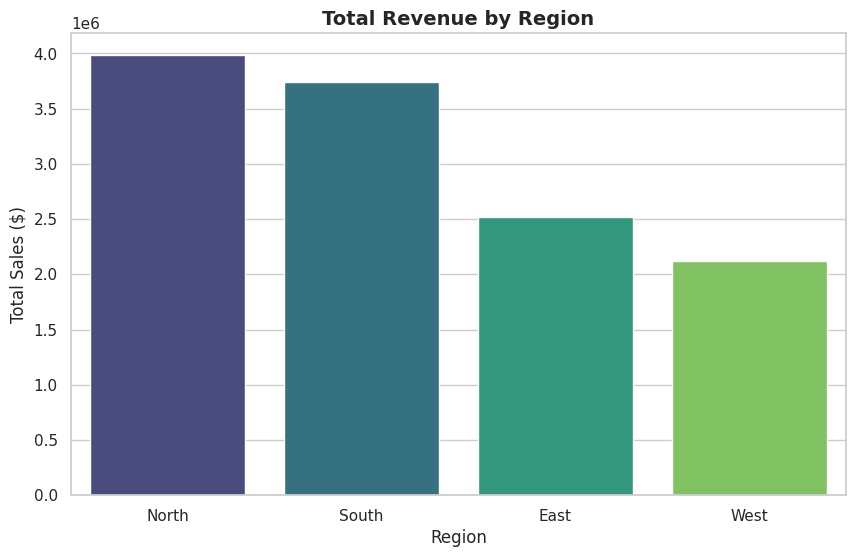

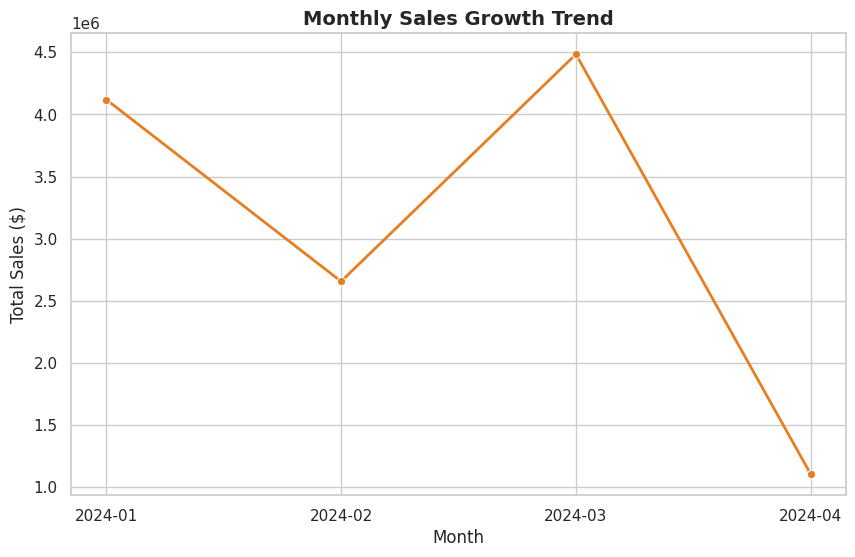

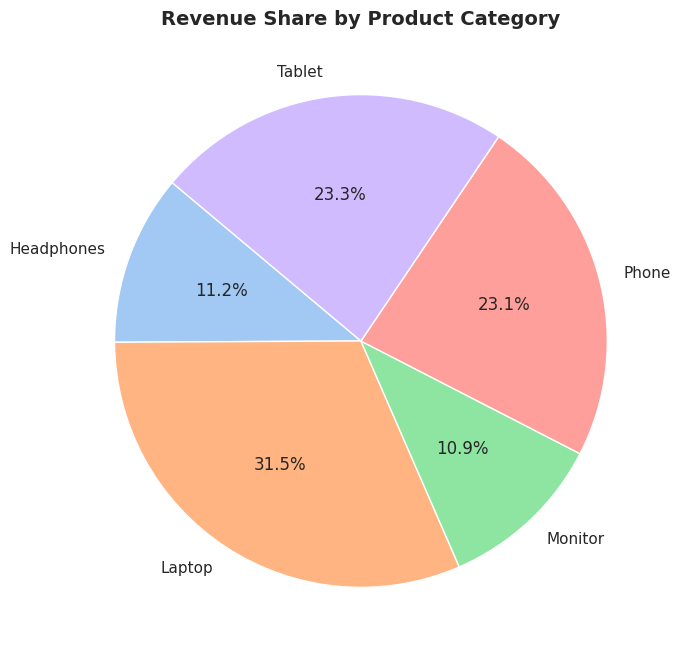

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration for professional plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

def run_sales_analysis(file_path):
    try:
        # --- 1. DATA LOADING ---
        df = pd.read_csv(file_path)
        print("✅ Data loaded successfully.")

        # --- 2. DATA CLEANING & PREPROCESSING ---
        df['Date'] = pd.to_datetime(df['Date'])
        df['Month'] = df['Date'].dt.strftime('%Y-%m')

        # Check for missing values
        if df.isnull().values.any():
            df = df.dropna()
            print("⚠️ Missing values detected and removed.")

        # --- 3. DATA ANALYSIS ---
        # Aggregate data for visualization
        region_sales = df.groupby('Region')['Total_Sales'].sum().reset_index().sort_values('Total_Sales', ascending=False)
        monthly_trend = df.groupby('Month')['Total_Sales'].sum().reset_index()
        product_sales = df.groupby('Product')['Total_Sales'].sum().reset_index()

        # --- 4. DATA VISUALIZATION ---

        # Chart 1: Sales by Region (Bar Chart)
        plt.figure()
        sns.barplot(data=region_sales, x='Region', y='Total_Sales', palette='viridis')
        plt.title('Total Revenue by Region', fontsize=14, fontweight='bold')
        plt.ylabel('Total Sales ($)')
        plt.savefig('sales_by_region.png')

        # Chart 2: Monthly Trend (Line Chart)
        plt.figure()
        sns.lineplot(data=monthly_trend, x='Month', y='Total_Sales', marker='o', color='#e67e22', linewidth=2)
        plt.title('Monthly Sales Growth Trend', fontsize=14, fontweight='bold')
        plt.ylabel('Total Sales ($)')
        plt.savefig('monthly_trend.png')

        # Chart 3: Product Share (Pie Chart)
        plt.figure(figsize=(8,8))
        plt.pie(product_sales['Total_Sales'], labels=product_sales['Product'], autopct='%1.1f%%',
                colors=sns.color_palette('pastel'), startangle=140)
        plt.title('Revenue Share by Product Category', fontsize=14, fontweight='bold')
        plt.savefig('product_share_pie.png')

        # --- 5. RESULTS EXPORT ---
        df.to_csv('cleaned_sales_analysis.csv', index=False)
        print("✅ Analysis complete. Charts and cleaned data have been saved.")

    except FileNotFoundError:
        print("❌ Error: The file 'sales_data.csv' was not found.")
    except Exception as e:
        print(f"❌ An unexpected error occurred: {e}")

# Run the analysis
run_sales_analysis('sales_data.csv')